### Import Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Analysis

In [43]:
# Reading data for csv file
raw = pd.read_csv("Gaming_and_Mental_Health.csv")

In [44]:
# Creating deep copy of the data
df = raw.copy(deep=True)

In [45]:
# Data preview
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [46]:
# Dataset shape
print(f"Shape of the Dataframe: {df.shape}")

Shape of the Dataframe: (1000, 27)


In [47]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [48]:
# Missing values
print(f"Missing values:\n{df.isna().sum()}")

Missing values:
record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_us

In [64]:
df.drop("record_id", axis=1, inplace=True)
df["grades_gpa"] = df["grades_gpa"].fillna(df["grades_gpa"].median())
df["work_productivity_score"] = df["work_productivity_score"].fillna(df["work_productivity_score"].median())

In [65]:
df.isna().sum()

age                                 0
gender                              0
daily_gaming_hours                  0
game_genre                          0
primary_game                        0
gaming_platform                     0
sleep_hours                         0
sleep_quality                       0
sleep_disruption_frequency          0
academic_work_performance           0
grades_gpa                          0
work_productivity_score             0
mood_state                          0
mood_swing_frequency                0
withdrawal_symptoms                 0
loss_of_other_interests             0
continued_despite_problems          0
eye_strain                          0
back_neck_pain                      0
weight_change_kg                    0
exercise_hours_weekly               0
social_isolation_score              0
face_to_face_social_hours_weekly    0
monthly_game_spending_usd           0
years_gaming                        0
gaming_addiction_risk_level         0
dtype: int64

In [66]:
# Df description
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.52098,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.75735,2.379219,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.01000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.99750,4.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.53000,5.394659,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.09000,7.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.00000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [74]:
sns.set_style("whitegrid")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

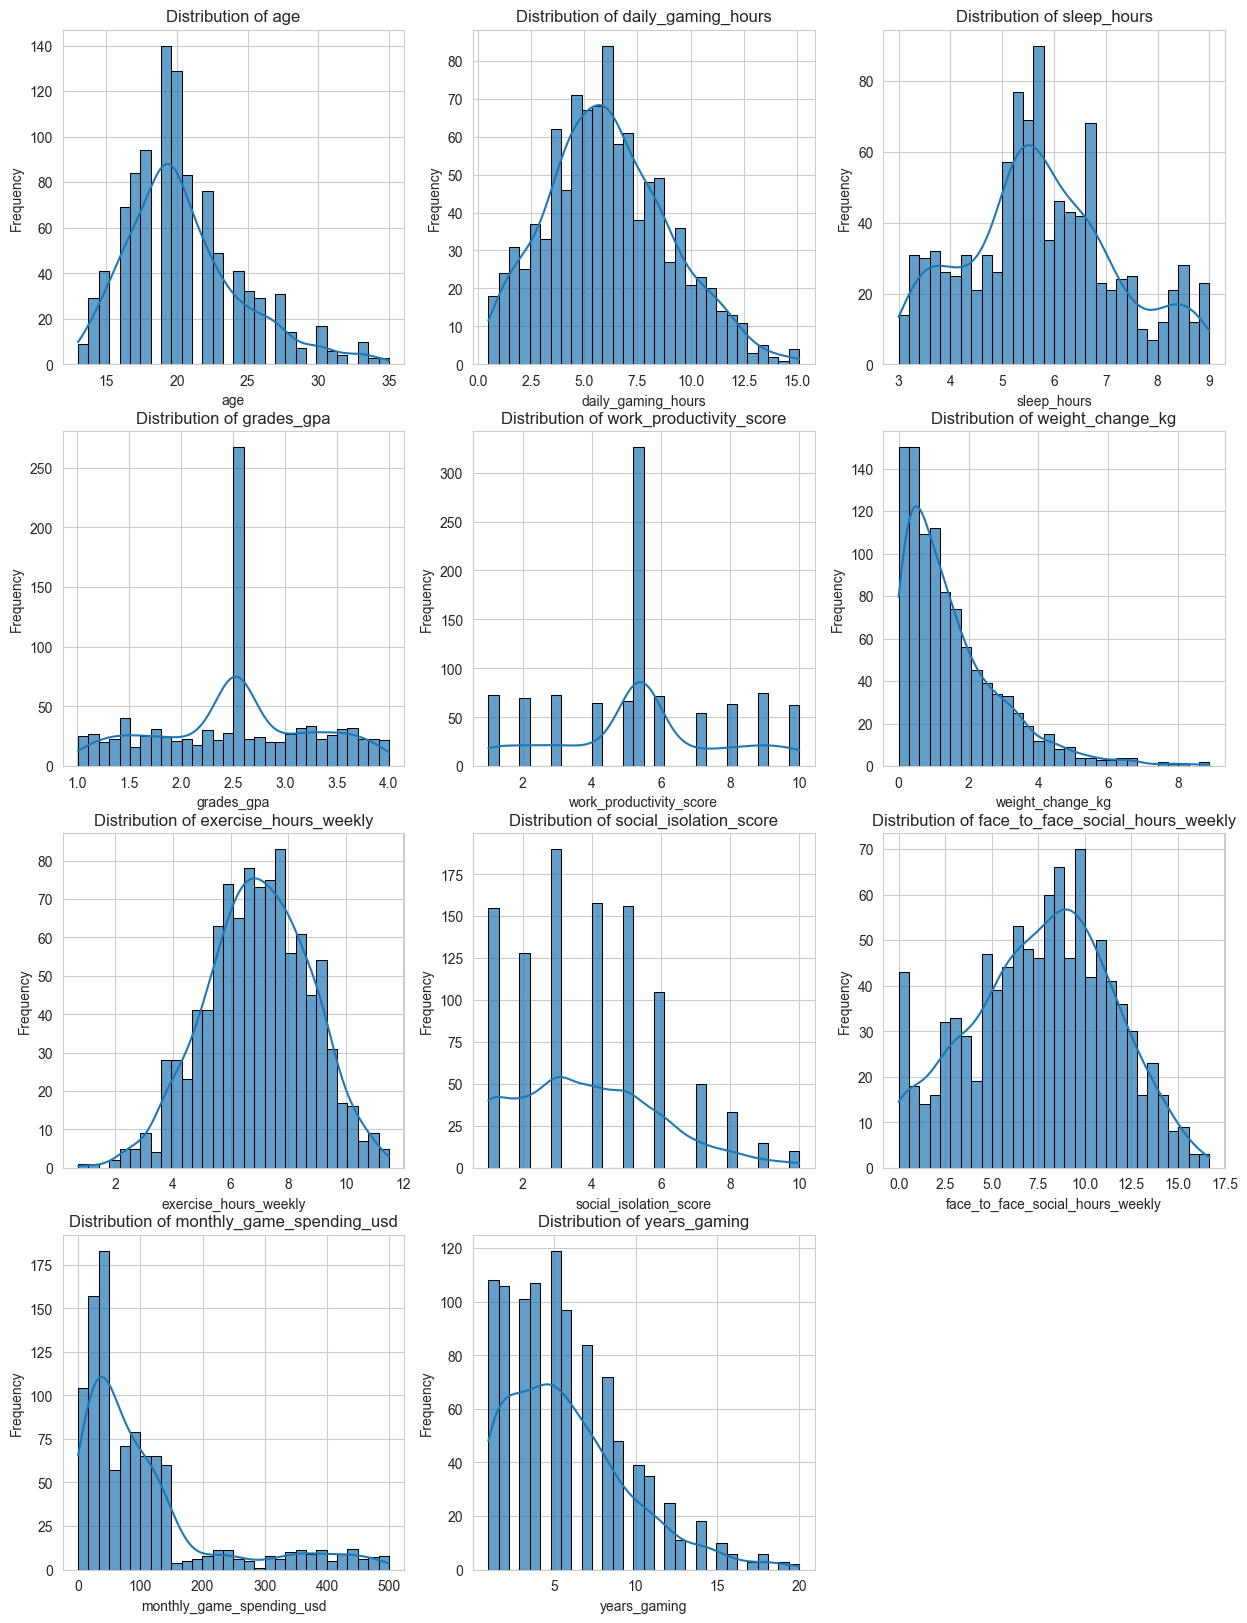

In [78]:
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3
    
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten()
    
for idx, col in enumerate(numerical_cols):
    sns.histplot(df[col],bins=30, ax=axes[idx], edgecolor='black', alpha=0.7, kde=True)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

axes[11].axis('off')
        

In [ ]:
n_cols = len(categorical_cols)
n_rows = (n_cols+2)//3
